<a href="https://colab.research.google.com/github/Frederick-Teye/ML-models/blob/main/PI_Assignment_Final_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

In [54]:
!pip install catboost

In [55]:
from catboost import CatBoostClassifier

In [56]:
ziya_data = pd.read_csv('drive/MyDrive/diabetes_data/diabetes_dataset_with_notes.csv')
ziya_data.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,"Overweight, advised dietary and exercise modif..."
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Healthy BMI range.
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,"Young patient, generally lower risk but needs ..."
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,"Overweight, advised dietary and exercise modif..."
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."


## Data Overview

This section is dedicated to getting a quick understanding of the `ziya_data` DataFrame. We'll examine its overall dimensions, identify the data type of each column, and thoroughly check for any missing values across the entire dataset. This will be achieved using methods like `.info()` to display a concise summary and `.isnull().sum()` to quantify any missing entries.


In [57]:
print(ziya_data.info())
print('\nMissing values per column:')
print(ziya_data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

## Descriptive Statistics

This section focuses on understanding the core characteristics of the ziya_data DataFrame. We'll start by calculating common statistical measures (like mean, median, standard deviation) for all numerical columns to see their typical values and how spread out they are. Then, for categorical columns, we'll look at how many unique categories exist and how often each category appears, helping us get a feel for the data's composition.


In [58]:
print('Descriptive statistics for numerical columns:')
print(ziya_data.describe())

print('\nValue counts for gender:')
print(ziya_data['gender'].value_counts())

print('\nUnique values and top 5 value counts for location:')
print(f"Number of unique locations: {ziya_data['location'].nunique()}")
print(ziya_data['location'].value_counts().head(5))

print('\nValue counts for smoking_history:')
print(ziya_data['smoking_history'].value_counts())

print('\nUnique values for clinical_notes:')
print(f"Number of unique clinical notes: {ziya_data['clinical_notes'].nunique()}")
print("The 'clinical_notes' column contains free-form text, which is not easily summarized by simple descriptive statistics.")

Descriptive statistics for numerical columns:
                year            age  race:AfricanAmerican     race:Asian  \
count  100000.000000  100000.000000         100000.000000  100000.000000   
mean     2018.360820      41.885856              0.202230       0.200150   
std         1.345239      22.516840              0.401665       0.400114   
min      2015.000000       0.080000              0.000000       0.000000   
25%      2019.000000      24.000000              0.000000       0.000000   
50%      2019.000000      43.000000              0.000000       0.000000   
75%      2019.000000      60.000000              0.000000       0.000000   
max      2022.000000      80.000000              1.000000       1.000000   

       race:Caucasian  race:Hispanic     race:Other  hypertension  \
count   100000.000000   100000.00000  100000.000000  100000.00000   
mean         0.198760        0.19888       0.199980       0.07485   
std          0.399069        0.39916       0.399987       0.26

## Distribution of Numerical Features

This section provides a visual overview of the distribution of key numerical features such as 'age', 'BMI', 'HbA1c level', and 'blood glucose level'. Using histograms with Kernel Density Estimates (KDE), we can observe the shape, central tendency, and spread of each feature, as well as identify any potential outliers or unusual patterns in their distributions.



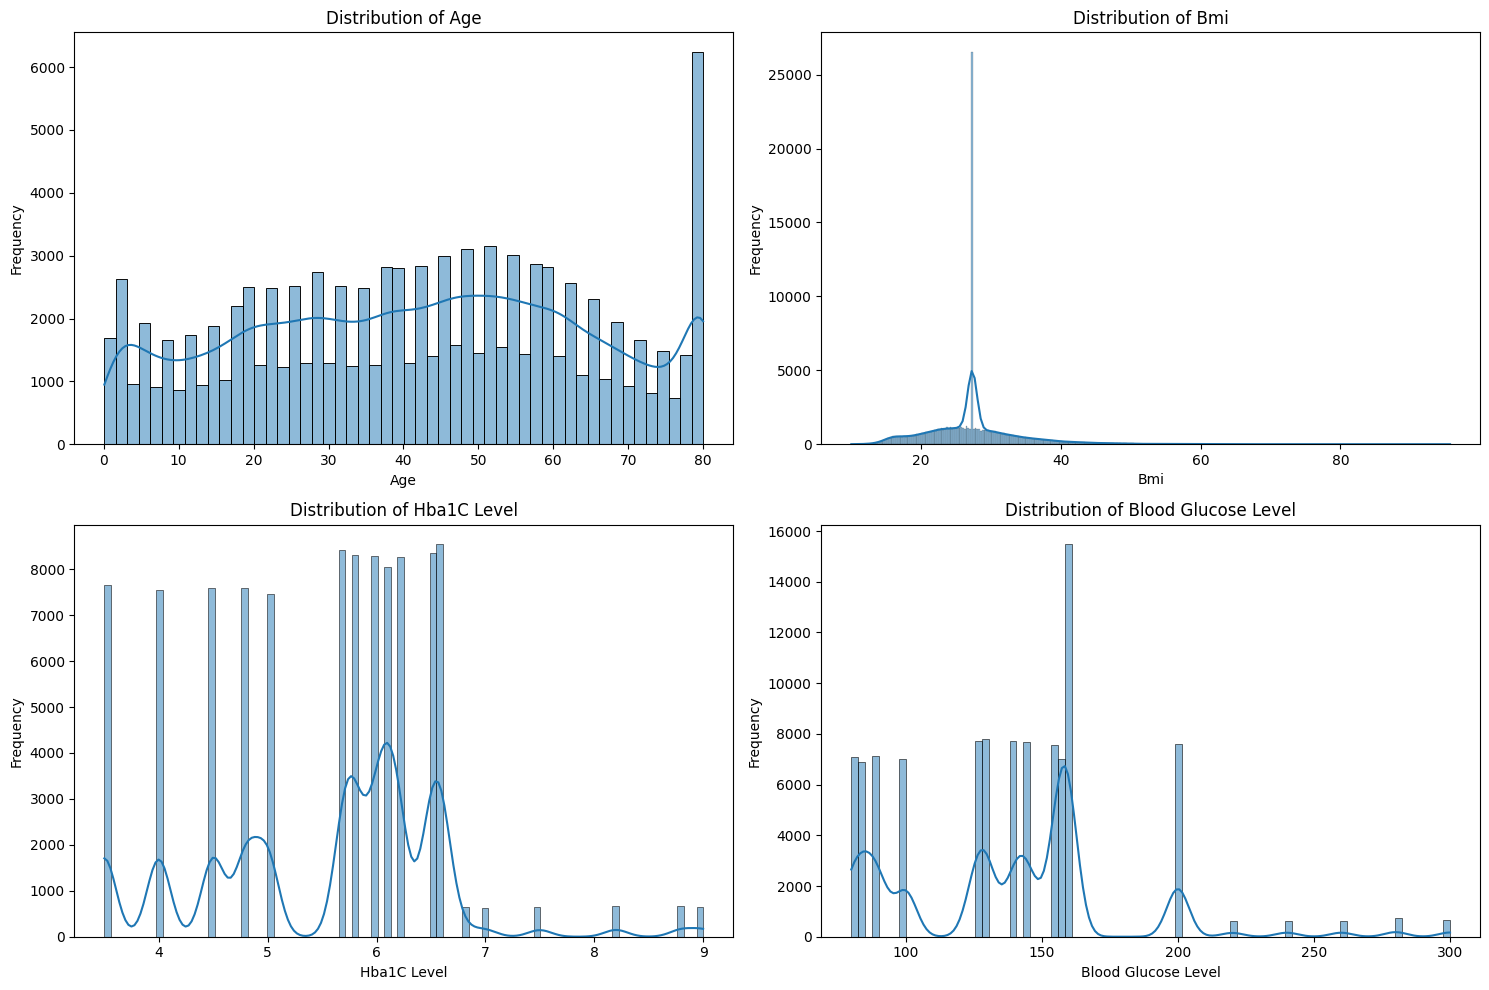

In [59]:
numerical_features = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']

plt.figure(figsize=(15, 10))

for i, feature in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid for the plots
    sns.histplot(ziya_data[feature], kde=True) # Use seaborn for nice histograms with KDE
    plt.title(f'Distribution of {feature.replace("_", " ").title()}')
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('Frequency')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()


## Distribution of Categorical Features

This section visually explores the distribution of key categorical features such as 'gender', 'smoking history', and 'location'. Using count plots, we can observe the frequency of each category within these features. For 'location', only the top 10 most frequent locations are displayed to provide a clear overview of the geographical representation in the dataset

/tmp/ipython-input-216/3039183812.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ziya_data, x='gender', palette='viridis')
/tmp/ipython-input-216/3039183812.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ziya_data, x='smoking_history', palette='magma')
/tmp/ipython-input-216/3039183812.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ziya_data[ziya_data['location'].isin(top_10_locations)], x='location', order=top_10_locations, palette='plasma')


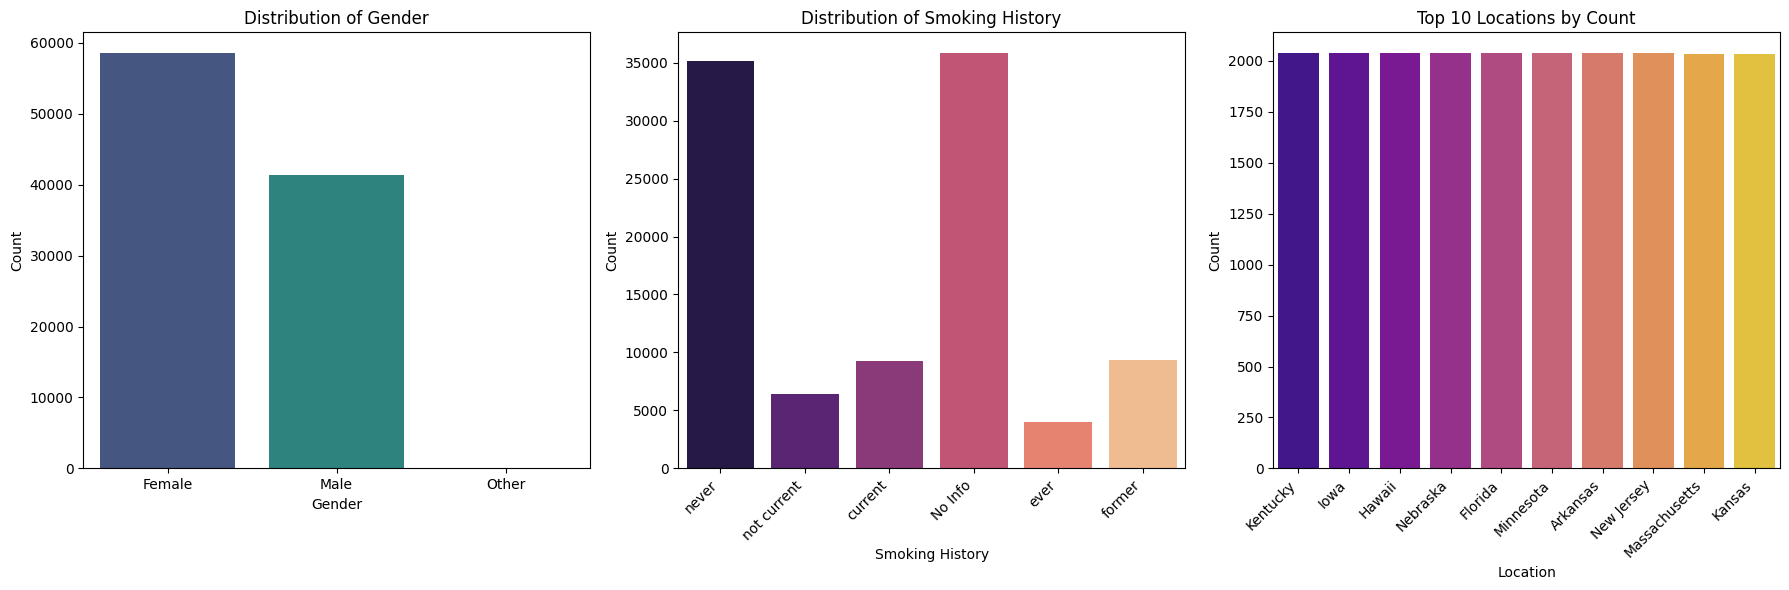

In [60]:
plt.figure(figsize=(18, 6))

# Plot for 'gender'
plt.subplot(1, 3, 1) # Create a 1x3 grid for the plots
sns.countplot(data=ziya_data, x='gender', palette='viridis')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

# Plot for 'smoking_history'
plt.subplot(1, 3, 2)
sns.countplot(data=ziya_data, x='smoking_history', palette='magma')
plt.title('Distribution of Smoking History')
plt.xlabel('Smoking History')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability

# Plot for 'location' (top 10)
top_10_locations = ziya_data['location'].value_counts().nlargest(10).index
plt.subplot(1, 3, 3)
sns.countplot(data=ziya_data[ziya_data['location'].isin(top_10_locations)], x='location', order=top_10_locations, palette='plasma')
plt.title('Top 10 Locations by Count')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

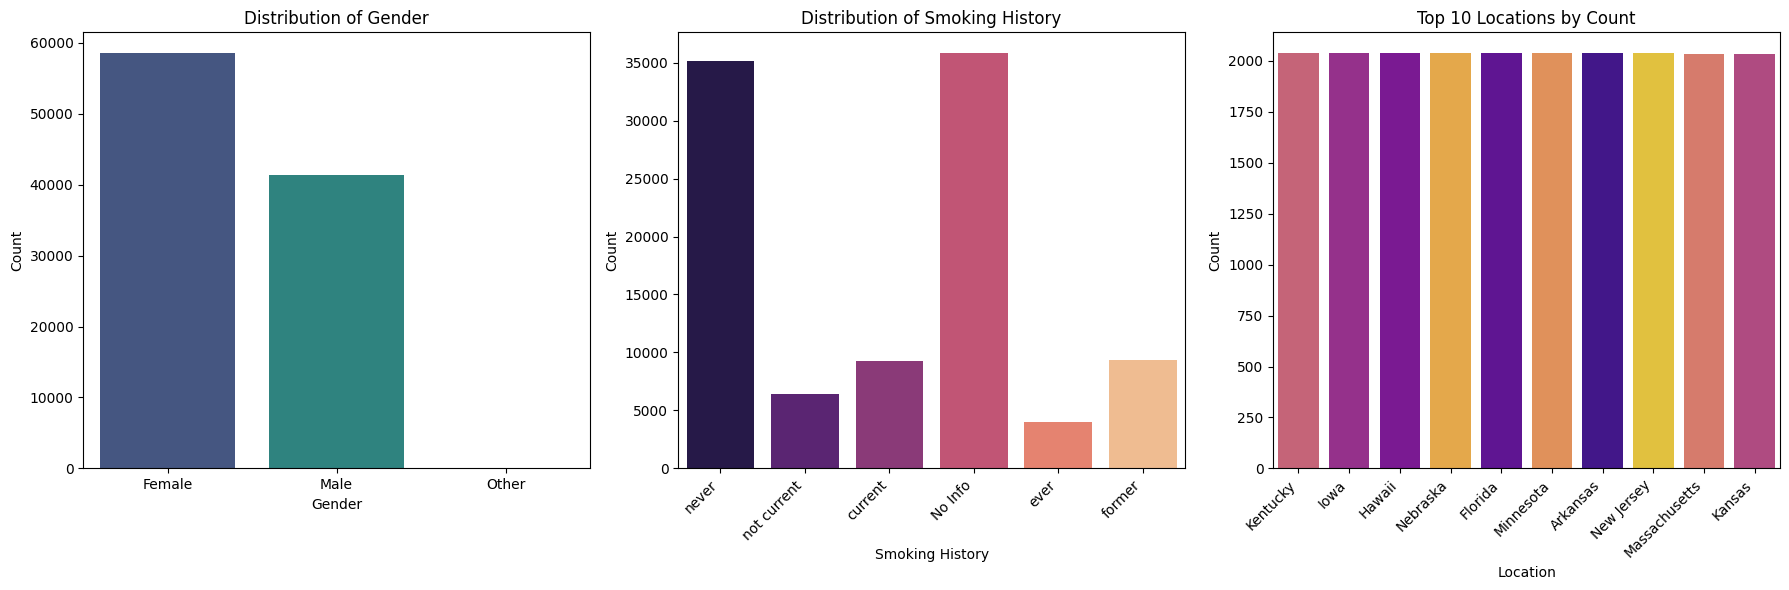

In [61]:
plt.figure(figsize=(18, 6))

# Plot for 'gender'
plt.subplot(1, 3, 1) # Create a 1x3 grid for the plots
sns.countplot(data=ziya_data, x='gender', hue='gender', palette='viridis', legend=False)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

# Plot for 'smoking_history'
plt.subplot(1, 3, 2)
sns.countplot(data=ziya_data, x='smoking_history', hue='smoking_history', palette='magma', legend=False)
plt.title('Distribution of Smoking History')
plt.xlabel('Smoking History')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability

# Plot for 'location' (top 10)
top_10_locations = ziya_data['location'].value_counts().nlargest(10).index
plt.subplot(1, 3, 3)
sns.countplot(data=ziya_data[ziya_data['location'].isin(top_10_locations)], x='location', order=top_10_locations, hue='location', palette='plasma', legend=False)
plt.title('Top 10 Locations by Count')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

## Relationship between Numerical Features and Diabetes Status

This section aims to visualize how key numerical features such as 'age', 'bmi', 'HbA1c level', and 'blood glucose level' relate to the 'diabetes' target variable. We will use box plots to examine if there are significant differences in the distributions of these numerical features between individuals with and without diabetes. Each plot will include clear titles and axis labels, with the layout adjusted to ensure readability.

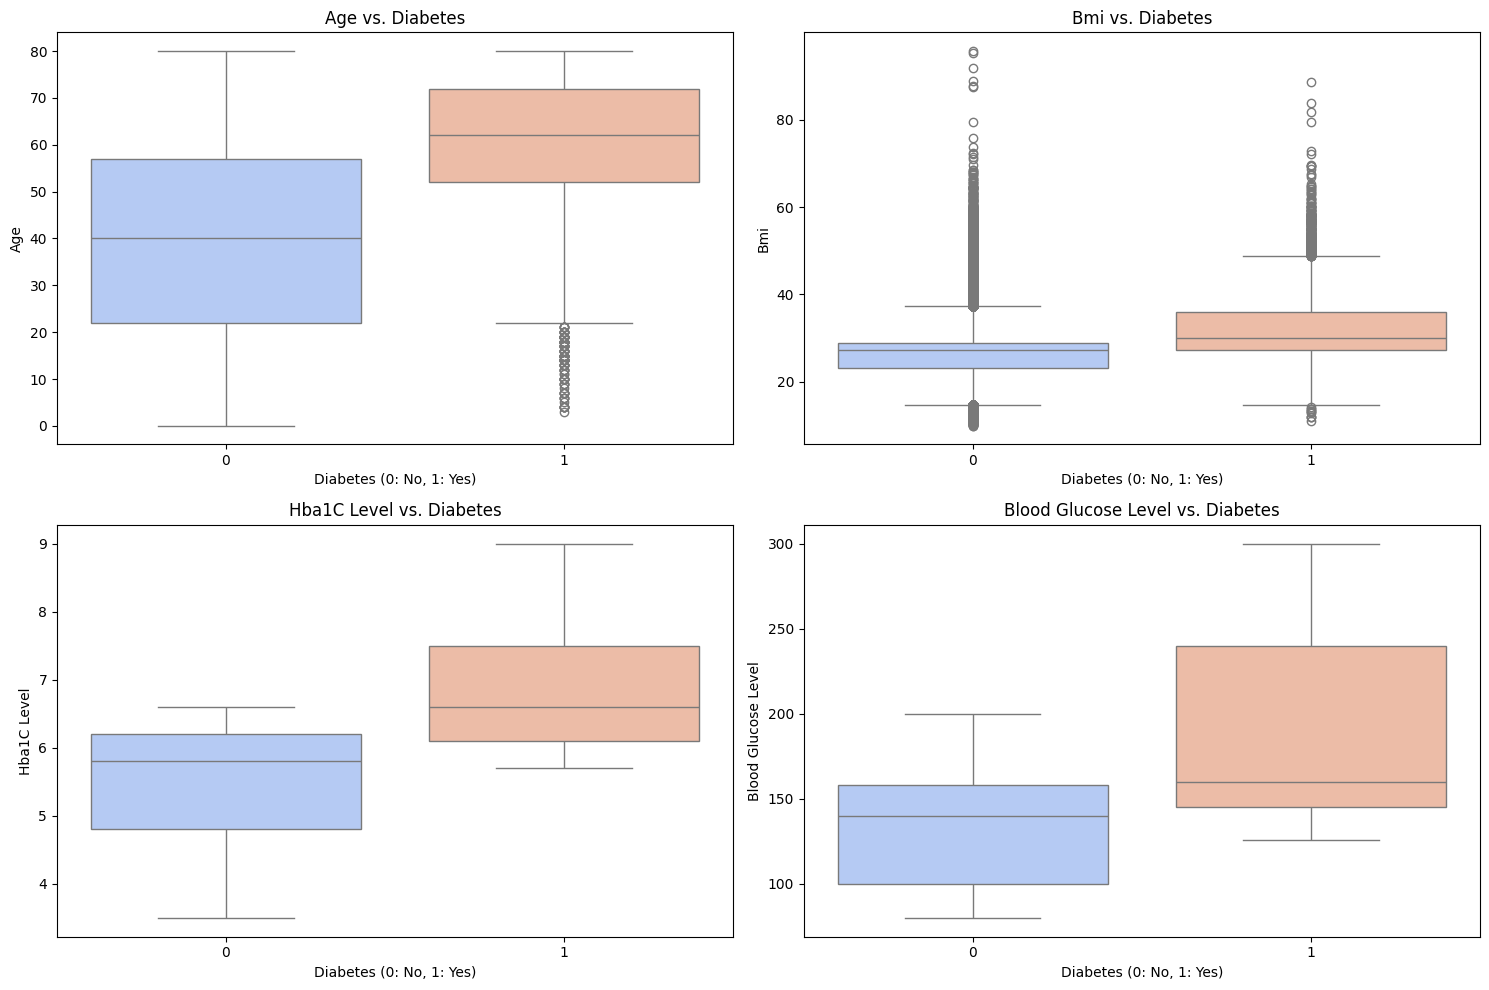

In [62]:
numerical_features = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']

plt.figure(figsize=(15, 10))

for i, feature in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid for the plots
    sns.boxplot(data=ziya_data, x='diabetes', hue='diabetes', y=feature, palette='coolwarm', legend=False) # Use seaborn for box plots
    plt.title(f'{feature.replace("_", " ").title()} vs. Diabetes')
    plt.xlabel('Diabetes (0: No, 1: Yes)')
    plt.ylabel(feature.replace("_", " ").title())

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

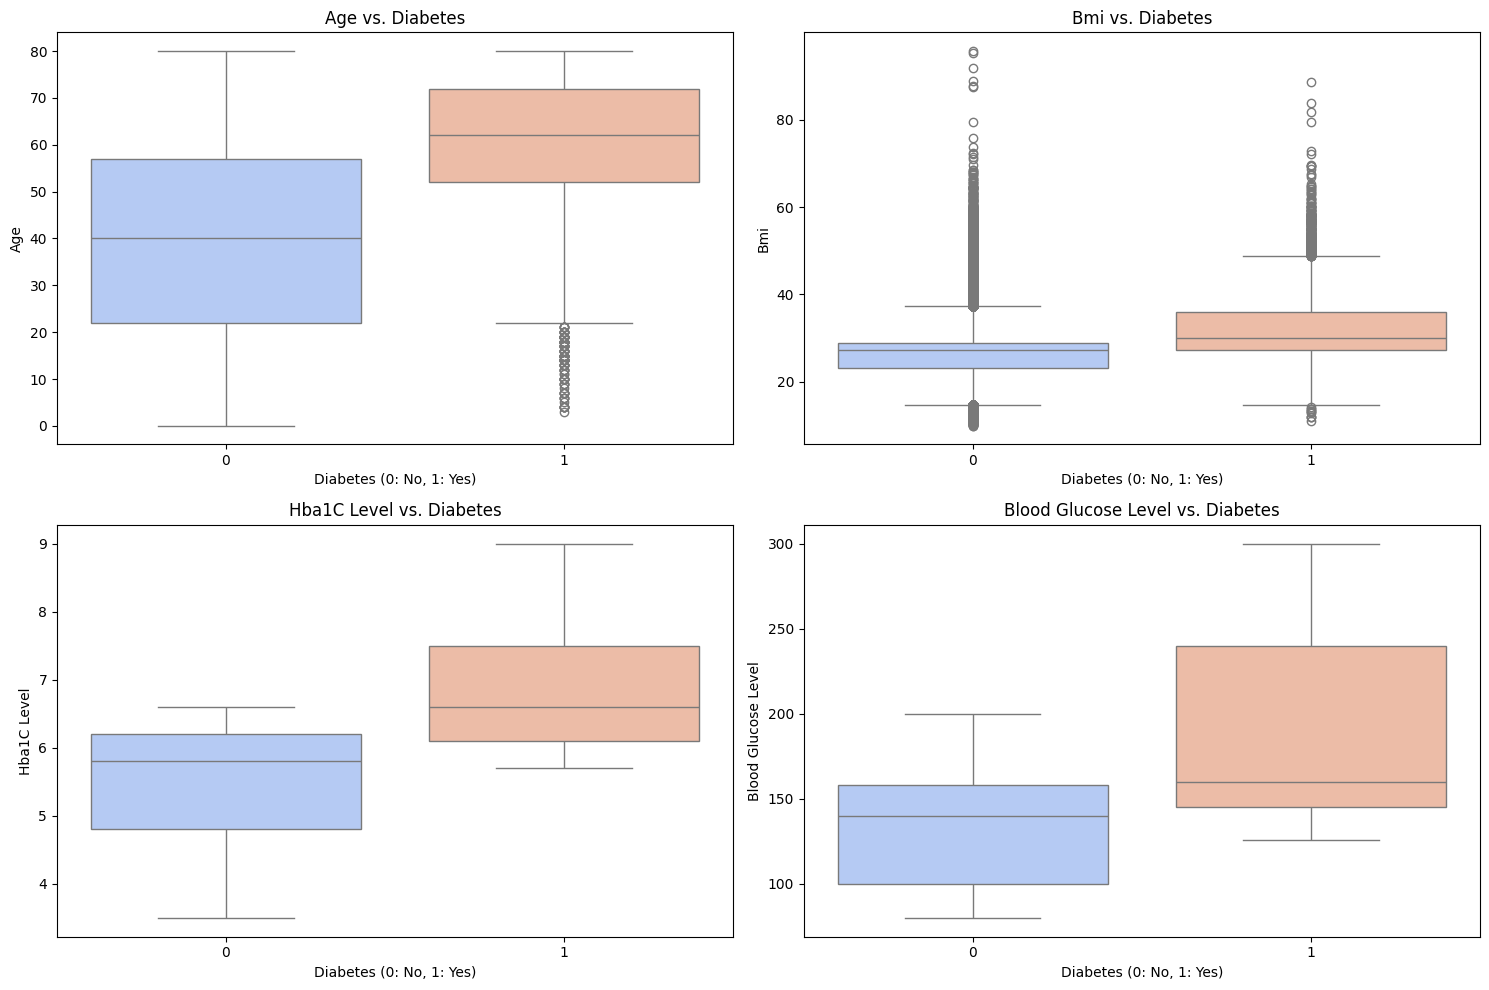

In [63]:
numerical_features = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']

plt.figure(figsize=(15, 10))

for i, feature in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid for the plots
    sns.boxplot(data=ziya_data, x='diabetes', y=feature, hue='diabetes', palette='coolwarm', legend=False) # Use seaborn for box plots
    plt.title(f'{feature.replace("_", " ").title()} vs. Diabetes')
    plt.xlabel('Diabetes (0: No, 1: Yes)')
    plt.ylabel(feature.replace("_", " ").title())

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

## Key Insights from Exploratory Data Analysis


### Summary of EDA Findings:

**1. Data Structure and Initial Observations:**
*   The `ziya_data` DataFrame contains 100,000 entries and 17 columns.
*   There are no missing values in any of the columns, which simplifies the data cleaning process.
*   Data types are appropriate, with `int64` for year and binary flags, `float64` for numerical measurements like age, bmi, HbA1c, and blood glucose, and `object` for categorical/text columns like gender, location, smoking_history, and clinical_notes.
*   The `clinical_notes` column is free-form text with 761 unique values, suggesting it might require natural language processing (NLP) if used for modeling, or could be dropped/simplified if not central to the current task.

**2. Distributions of Numerical Features:**
*   **Age:** The age distribution appears to be bimodal, with peaks in younger and older age groups. The mean age is around 41.89 years, and the distribution covers a wide range from infants (0.08 years) to 80 years.
*   **BMI:** The BMI distribution is roughly normal with a slight right skew, centered around 27.32. There are some outliers with very high BMI values, indicating potential obesity cases.
*   **HbA1c Level:** This feature shows a multi-modal distribution, with distinct peaks. Values higher than 6.5 are indicative of diabetes. The mean is 5.53.
*   **Blood Glucose Level:** Similar to HbA1c, this also exhibits a multi-modal distribution, with clear peaks at values around 100 (normal), 140 (pre-diabetic), and higher (diabetic). The mean is 138.06.

**3. Distributions of Categorical Features:**
*   **Gender:** The dataset is predominantly female (approx. 58.55%) with a significant number of male entries (approx. 41.43%). A small 'Other' category exists but is negligible.
*   **Location:** There are 55 unique locations. The distribution across locations is relatively even for the top 10, with states like Kentucky, Iowa, Hawaii, Nebraska, and Florida having slightly higher counts. This indicates a diverse geographical representation.
*   **Smoking History:** The 'No Info' and 'never' categories are the most frequent, each accounting for about 35% of the data. 'Former' and 'current' smokers make up smaller, but significant, portions, while 'not current' and 'ever' are the least frequent.

**4. Relationships with 'Diabetes' Target Variable:**
*   **Age vs. Diabetes:** Box plots indicate a clear trend: individuals with diabetes (Diabetes=1) generally have higher ages compared to those without diabetes (Diabetes=0). The median age for diabetics is noticeably higher.
*   **BMI vs. Diabetes:** Individuals with diabetes tend to have higher BMI values. While there's overlap, the median BMI for diabetics is significantly greater, and the distribution for diabetics extends to higher BMI ranges, suggesting obesity as a risk factor.
*   **HbA1c Level vs. Diabetes:** This shows the strongest correlation. Diabetics (Diabetes=1) have significantly higher HbA1c levels, with very little overlap with non-diabetics (Diabetes=0). This is expected, as HbA1c is a primary diagnostic marker for diabetes.
*   **Blood Glucose Level vs. Diabetes:** Similar to HbA1c, blood glucose levels are markedly higher in individuals with diabetes. The median and spread for diabetics are considerably elevated, reinforcing its role as a key indicator.

**5. Readiness for Modeling and Preprocessing Needs:**
*   The dataset is clean regarding missing values, making it ready for immediate analysis and modeling.
*   Categorical features (`gender`, `location`, `smoking_history`) will need encoding (e.g., OneHotEncoding) for most machine learning models.
*   The `race:` columns are already in a one-hot encoded-like format, which is beneficial.
*   The 'clinical_notes' column might require feature engineering (e.g., text embeddings, keyword extraction) or could be excluded depending on the model's complexity and the specific analytical goals.
*   The imbalance in the 'diabetes' target variable (only 8.5% positive cases) suggests that stratified sampling during cross-validation and appropriate evaluation metrics (e.g., precision, recall, F1-score, AUC-ROC) will be crucial for model training and assessment.

## Corelation
Even though we can clearly see the correlation above, I am going to do a heatmap to show the correlation between the numeric values and diabetes in a headmap.

In [64]:
female_df = ziya_data[ziya_data.gender=="Female"]
female_df
cleaned_female_df = female_df.drop(['gender', 'location', 'race:AfricanAmerican',
       'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'clinical_notes', 'smoking_history'], axis=1)
cleaned_female_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58552 entries, 0 to 99998
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 58552 non-null  int64  
 1   age                  58552 non-null  float64
 2   hypertension         58552 non-null  int64  
 3   heart_disease        58552 non-null  int64  
 4   bmi                  58552 non-null  float64
 5   hbA1c_level          58552 non-null  float64
 6   blood_glucose_level  58552 non-null  int64  
 7   diabetes             58552 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 4.0 MB


In [65]:
female_corr_df = cleaned_female_df.corr()

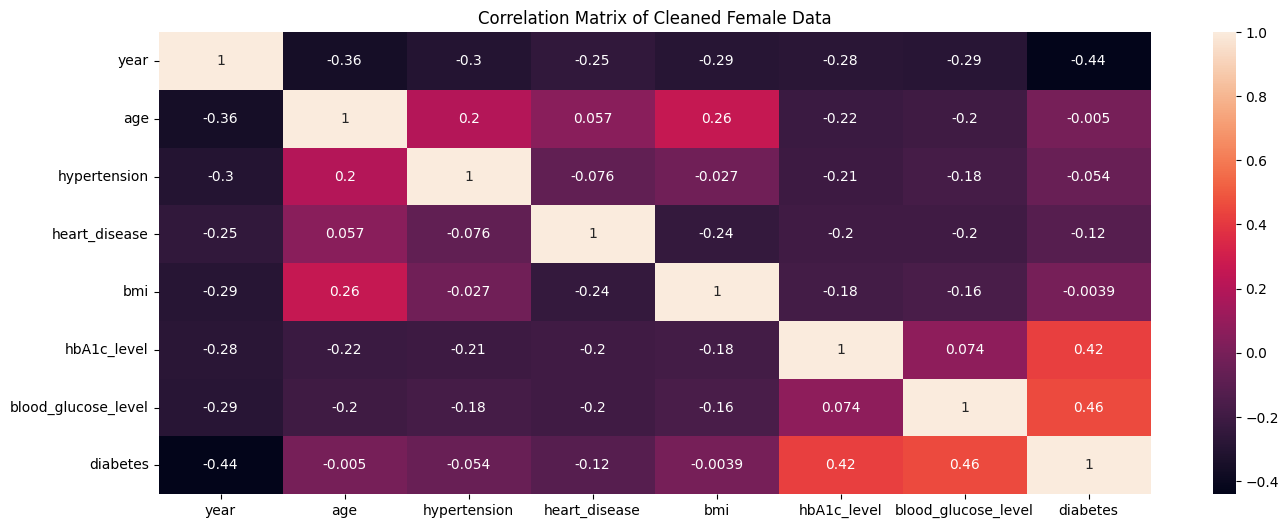

In [66]:
plt.figure(figsize=(16, 6))
sns.heatmap(data=female_corr_df.corr(), annot=True)
plt.title('Correlation Matrix of Cleaned Female Data')
plt.show()

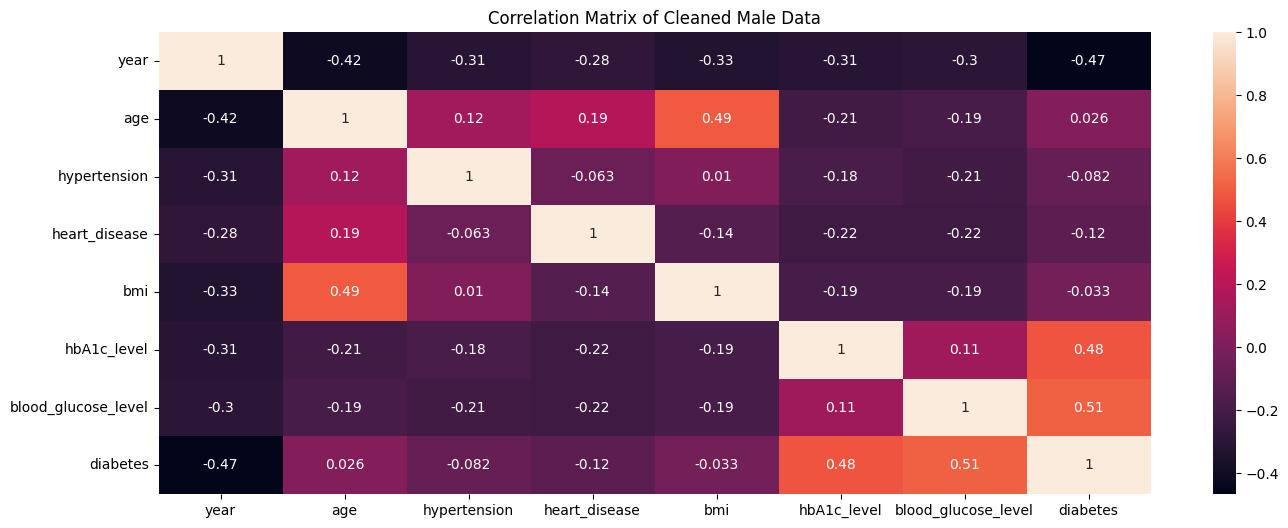

In [67]:
male_df = ziya_data[ziya_data.gender=="Male"].drop(['gender', 'location', 'race:AfricanAmerican',
       'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'clinical_notes', 'smoking_history'], axis=1)
male_corr_df = male_df.corr()
plt.figure(figsize=(16, 6))
sns.heatmap(data=male_corr_df.corr(), annot=True)
plt.title('Correlation Matrix of Cleaned Male Data')
plt.show()

## What type of diabetes is Ziya Data about?

I was wondering this and then I had to go investigate from the clinical notes and as I was exploring the notes using my pandas skills I got to see that the data was for Type 2 diabetes.

In [68]:
ziya_data.loc[35, 'clinical_notes']

'Elderly patient with increased risk of chronic conditions. Overweight, advised dietary and exercise modifications. Elevated blood glucose levels, potential diabetes concern. High HbA1c level, indicative of diabetes or poor glucose control. Cardiac condition present, high cardiovascular risk. Consideration for metabolic syndrome and Type 2 diabetes.'

In [69]:
ziya_data.loc[28, 'clinical_notes']

'Overweight, advised dietary and exercise modifications. Elevated blood glucose levels, potential diabetes concern. Consideration for metabolic syndrome and Type 2 diabetes.'

# Models

I explored ensamble models using this dataset.

## XGBoost Models

In [70]:
df_processed = ziya_data.drop(columns=['location', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'clinical_notes', 'year', 'blood_glucose_level', 'hbA1c_level'])
df_processed.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,diabetes
0,Female,32.0,0,0,never,27.32,0
1,Female,29.0,0,0,never,19.95,0
2,Male,18.0,0,0,never,23.76,0
3,Male,41.0,0,0,never,27.32,0
4,Female,52.0,0,0,never,23.75,0


In [71]:
# THE CUSTOM DATA SPLIT (The 50/50 Classroom vs 86k Reality)
df_majority = df_processed[df_processed['diabetes'] == 0]
df_minority = df_processed[df_processed['diabetes'] == 1]

# Split Minority
df_minority = shuffle(df_minority, random_state=42)
min_train_size = int(len(df_minority) * 0.8)

minority_train = df_minority.iloc[:min_train_size]
minority_test = df_minority.iloc[min_train_size:]

# Split Majority
df_majority = shuffle(df_majority, random_state=42)

majority_train = df_majority.iloc[:min_train_size]
majority_test = df_majority.iloc[min_train_size:]

# Recombine
train_data = shuffle(pd.concat([majority_train, minority_train]), random_state=42)
test_data = shuffle(pd.concat([majority_test, minority_test]), random_state=42)

X_train = train_data.drop('diabetes', axis=1)
y_train = train_data['diabetes']

X_test = test_data.drop('diabetes', axis=1)
y_test = test_data['diabetes']

print(f"--- Data Architecture Confirmed ---")
print(f"Training Set (Class 0 vs 1): {sum(y_train==0)} vs {sum(y_train==1)}")
print(f"Testing Set  (Class 0 vs 1): {sum(y_test==0)} vs {sum(y_test==1)}\n")


# THE PIPELINE & PREPROCESSOR
categorical_cols = ['gender', 'smoking_history']
numeric_cols = ['age', 'hypertension', 'heart_disease', 'bmi']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', xgb.XGBClassifier(eval_metric='logloss', random_state=42))
])


# HYPERPARAMETER TUNING GRID

# Reintroduce the grid to find the optimal balance between
# model complexity and regularization (preventing False Positives).
param_distributions = {
    'xgb__n_estimators': [100, 200, 300, 500, 900],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__max_depth': [3, 5, 6, 7, 9],
    'xgb__min_child_weight': [1, 3, 5, 7],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 0.9, 1.0],
    'xgb__gamma': [0, 0.1, 0.5, 1, 5]
}

# RANDOMIZED SEARCH CV CONFIGURATION
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='f1',       # Specifically ask it to optimize the F1-score!
    cv=cv_strategy,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# TRAINING & THE ULTIMATE REALITY CHECK
print("Starting Hyperparameter Tuning on the 50/50 training dataset")
random_search.fit(X_train, y_train)

print(f"\nBest Hyperparameters Found:\n{random_search.best_params_}")

# Extract the tuned model
best_pipeline = random_search.best_estimator_

print("\nDeploying TUNED model to the grueling 86k-row reality test...")
y_pred = best_pipeline.predict(X_test)

print("\n--- Final Tuned Model Performance ---")
print(classification_report(y_test, y_pred))

--- Data Architecture Confirmed ---
Training Set (Class 0 vs 1): 6800 vs 6800
Testing Set  (Class 0 vs 1): 84700 vs 1700

Starting Hyperparameter Tuning on the 50/50 training dataset
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Hyperparameters Found:
{'xgb__subsample': 0.6, 'xgb__n_estimators': 200, 'xgb__min_child_weight': 5, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.01, 'xgb__gamma': 0.5, 'xgb__colsample_bytree': 0.8}

Deploying TUNED model to the grueling 86k-row reality test...

--- Final Tuned Model Performance ---
              precision    recall  f1-score   support

           0       1.00      0.68      0.81     84700
           1       0.05      0.84      0.09      1700

    accuracy                           0.68     86400
   macro avg       0.52      0.76      0.45     86400
weighted avg       0.98      0.68      0.79     86400



In [72]:
# Generate the raw confusion matrix array
cm = confusion_matrix(y_test, y_pred)

# Unpack the matrix into our four specific variables.
tn, fp, fn, tp = cm.ravel()

print("             ABSOLUTE PREDICTION COUNTS")
print("--------------------------------------------------------")
print(f"True Negatives  (Correctly identified as Healthy): {tn}")
print(f"False Positives (Accidentally flagged as Sick):    {fp}")
print(f"False Negatives (Missed actual Diabetes cases):    {fn}")
print(f"True Positives  (Correctly identified Diabetes):   {tp}\n")

print("--- Standard Classification Report ---")
print(classification_report(y_test, y_pred))

             ABSOLUTE PREDICTION COUNTS
--------------------------------------------------------
True Negatives  (Correctly identified as Healthy): 57507
False Positives (Accidentally flagged as Sick):    27193
False Negatives (Missed actual Diabetes cases):    277
True Positives  (Correctly identified Diabetes):   1423

--- Standard Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.68      0.81     84700
           1       0.05      0.84      0.09      1700

    accuracy                           0.68     86400
   macro avg       0.52      0.76      0.45     86400
weighted avg       0.98      0.68      0.79     86400



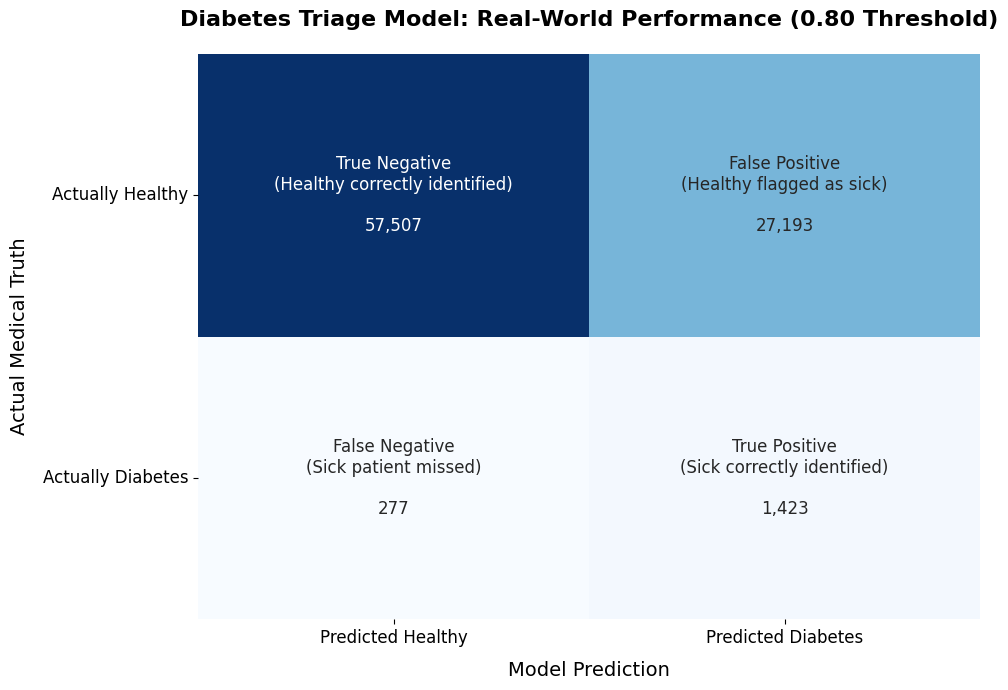

In [73]:
cm = confusion_matrix(y_test, y_pred)

group_names = [
    "True Negative\n(Healthy correctly identified)",
    "False Positive\n(Healthy flagged as sick)",
    "False Negative\n(Sick patient missed)",
    "True Positive\n(Sick correctly identified)"
]

# flatten the matrix to easily zip it with our names
group_counts = [f"{value:,.0f}" for value in cm.flatten()]

# combined the name and the count into a single string for each box
labels = [f"{v1}\n\n{v2}" for v1, v2 in zip(group_names, group_counts)]

# Reshape the labels back into the 2x2 grid format Seaborn expects
labels = np.asarray(labels).reshape(2, 2)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    annot_kws={"size": 12})

plt.title("Diabetes Triage Model: Real-World Performance (0.80 Threshold)",
          fontsize=16, pad=20, fontweight='bold')

plt.xlabel("Model Prediction", fontsize=14, labelpad=10)
plt.xticks(ticks=[0.5, 1.5], labels=["Predicted Healthy", "Predicted Diabetes"], fontsize=12)

plt.ylabel("Actual Medical Truth", fontsize=14, labelpad=10)
plt.yticks(ticks=[0.5, 1.5], labels=["Actually Healthy", "Actually Diabetes"],
           fontsize=12, rotation=0)

plt.tight_layout()
plt.show()

/tmp/ipython-input-216/2955440881.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


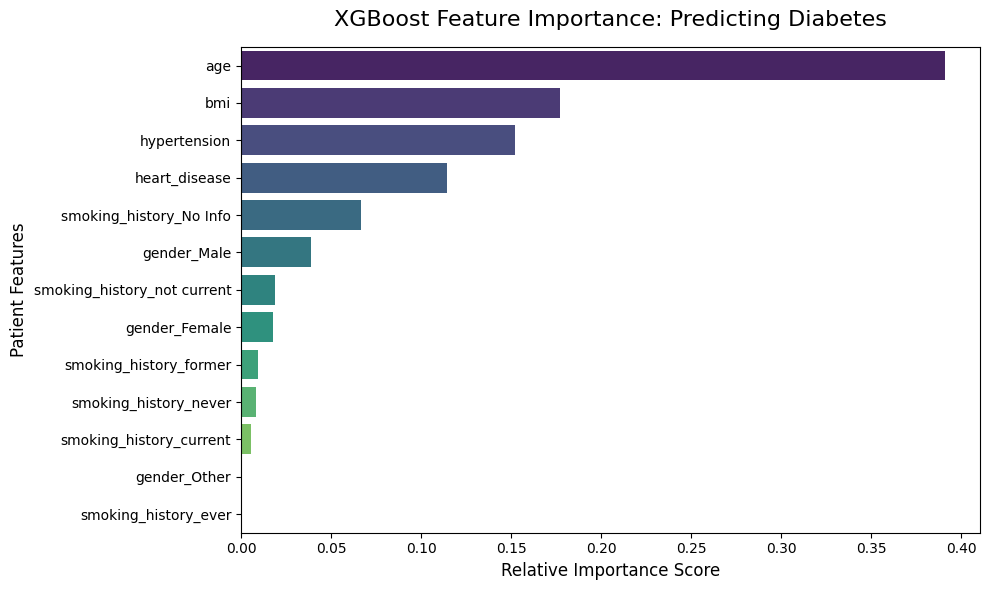

In [74]:
tuned_xgb_model = best_pipeline.named_steps['xgb']
preprocessor = best_pipeline.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()

# Cleaned up the names for the graph (to remove the prefix)
clean_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]

# I grab the mathematical importance scores calculated by XGBoost
importances = tuned_xgb_model.feature_importances_

# Bind the names to the scores in a Pandas DataFrame and sort them
importance_df = pd.DataFrame({
    'Feature': clean_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')

plt.title("XGBoost Feature Importance: Predicting Diabetes", fontsize=16, pad=15)
plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("Patient Features", fontsize=12)

# Add standard layout formatting so labels don't get cut off
plt.tight_layout()
plt.show()

In [75]:
df_majority = df_processed[df_processed['diabetes'] == 0]
df_minority = df_processed[df_processed['diabetes'] == 1]

# Split Minority (80% Train, 20% Test)
df_minority = shuffle(df_minority, random_state=42)
min_train_size = int(len(df_minority) * 0.8)

minority_train = df_minority.iloc[:min_train_size]
minority_test = df_minority.iloc[min_train_size:]

df_majority = shuffle(df_majority, random_state=42)

majority_train = df_majority.iloc[:min_train_size]
majority_test = df_majority.iloc[min_train_size:]

train_data = shuffle(pd.concat([majority_train, minority_train]), random_state=42)
test_data = shuffle(pd.concat([majority_test, minority_test]), random_state=42)

X_train = train_data.drop('diabetes', axis=1)
y_train = train_data['diabetes']

X_test = test_data.drop('diabetes', axis=1)
y_test = test_data['diabetes']

categorical_cols = ['gender', 'smoking_history']
numeric_cols = ['age', 'hypertension', 'heart_disease', 'bmi']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)


manual_params = {
    'n_estimators': 200,
    'learning_rate': 0.1,
    'max_depth': 3,
    'min_child_weight': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 1,
    'eval_metric': 'logloss',
    'random_state': 42
}

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', xgb.XGBClassifier(**manual_params))
])

print("Training the manual model on the 50/50 training dataset")
pipeline.fit(X_train, y_train)

custom_threshold = 0.50
print(f"\nEvaluating with Custom Threshold: {custom_threshold}")

y_pred_probabilities = pipeline.predict_proba(X_test)[:, 1]
y_pred_custom = (y_pred_probabilities >= custom_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_custom)
tn, fp, fn, tp = cm.ravel()

print("\n             ABSOLUTE PREDICTION COUNTS")
print("------------------------------------------------------")
print(f"True Negatives  (Correctly identified as Healthy): {tn}")
print(f"False Positives (Accidentally flagged as Sick):    {fp}")
print(f"False Negatives (Missed actual Diabetes cases):    {fn}")
print(f"True Positives  (Correctly identified Diabetes):   {tp}\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred_custom))

Training the manual model on the 50/50 training dataset

Evaluating with Custom Threshold: 0.5

             ABSOLUTE PREDICTION COUNTS
------------------------------------------------------
True Negatives  (Correctly identified as Healthy): 61664
False Positives (Accidentally flagged as Sick):    23036
False Negatives (Missed actual Diabetes cases):    340
True Positives  (Correctly identified Diabetes):   1360

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.73      0.84     84700
           1       0.06      0.80      0.10      1700

    accuracy                           0.73     86400
   macro avg       0.53      0.76      0.47     86400
weighted avg       0.98      0.73      0.83     86400



In [76]:
df_majority = df_processed[df_processed['diabetes'] == 0]
df_minority = df_processed[df_processed['diabetes'] == 1]

df_minority = shuffle(df_minority, random_state=42)
min_train_size = int(len(df_minority) * 0.8)

minority_train = df_minority.iloc[:min_train_size]
minority_test = df_minority.iloc[min_train_size:]

df_majority = shuffle(df_majority, random_state=42)

majority_train = df_majority.iloc[:min_train_size]
majority_test = df_majority.iloc[min_train_size:]

train_data = shuffle(pd.concat([majority_train, minority_train]), random_state=42)
test_data = shuffle(pd.concat([majority_test, minority_test]), random_state=42)

X_train = train_data.drop('diabetes', axis=1)
y_train = train_data['diabetes']

X_test = test_data.drop('diabetes', axis=1)
y_test = test_data['diabetes']

categorical_cols = ['gender', 'smoking_history']
numeric_cols = ['age', 'hypertension', 'heart_disease', 'bmi']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

manual_params = {
    'n_estimators': 20,
    'learning_rate': 0.1,
    'max_depth': 2,
    'min_child_weight': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 1,
    'eval_metric': 'logloss',
    'random_state': 42
}

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', xgb.XGBClassifier(**manual_params))
])

print("Training the manual model on the 50/50 training dataset")
pipeline.fit(X_train, y_train)

custom_threshold = 0.50
print(f"\nEvaluating with Custom Threshold: {custom_threshold}")

y_pred_probabilities = pipeline.predict_proba(X_test)[:, 1]
y_pred_custom = (y_pred_probabilities >= custom_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_custom)
tn, fp, fn, tp = cm.ravel()

print("\n             ABSOLUTE PREDICTION COUNTS")
print("------------------------------------------------------")
print(f"True Negatives  (Correctly identified as Healthy): {tn}")
print(f"False Positives (Accidentally flagged as Sick):    {fp}")
print(f"False Negatives (Missed actual Diabetes cases):    {fn}")
print(f"True Positives  (Correctly identified Diabetes):   {tp}\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred_custom))

print("\n--------- Parameters -----------")
print(manual_params)

Training the manual model on the 50/50 training dataset

Evaluating with Custom Threshold: 0.5

             ABSOLUTE PREDICTION COUNTS
------------------------------------------------------
True Negatives  (Correctly identified as Healthy): 55261
False Positives (Accidentally flagged as Sick):    29439
False Negatives (Missed actual Diabetes cases):    251
True Positives  (Correctly identified Diabetes):   1449

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.65      0.79     84700
           1       0.05      0.85      0.09      1700

    accuracy                           0.66     86400
   macro avg       0.52      0.75      0.44     86400
weighted avg       0.98      0.66      0.77     86400


--------- Parameters -----------
{'n_estimators': 20, 'learning_rate': 0.1, 'max_depth': 2, 'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 1, 'eval_metric': 'logloss', 'random_state': 42}


In [77]:
print("             THRESHOLD SWEEP ANALYSIS")
print("---------------------------------------------------\n")

# Get the raw probabilities once (saves computation time)
y_pred_probabilities = pipeline.predict_proba(X_test)[:, 1]

# We will test thresholds from 0.50 up to 0.80
thresholds_to_test = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

for thresh in thresholds_to_test:
    # Apply the threshold
    y_pred_custom = (y_pred_probabilities >= thresh).astype(int)

    # Calculate the matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom).ravel()

    # Calculate Precision and Recall manually to prevent division by zero errors
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    print(f"--- Threshold: {thresh:.2f} ---")
    print(f"Caught (TP): {tp}  |  Missed (FN): {fn}")
    print(f"False Alarms (FP): {fp}")
    print(f"Recall: {recall:.2%}  |  Precision: {precision:.2%}\n")


             THRESHOLD SWEEP ANALYSIS
---------------------------------------------------

--- Threshold: 0.50 ---
Caught (TP): 1449  |  Missed (FN): 251
False Alarms (FP): 29439
Recall: 85.24%  |  Precision: 4.69%

--- Threshold: 0.55 ---
Caught (TP): 1346  |  Missed (FN): 354
False Alarms (FP): 24310
Recall: 79.18%  |  Precision: 5.25%

--- Threshold: 0.60 ---
Caught (TP): 1031  |  Missed (FN): 669
False Alarms (FP): 13104
Recall: 60.65%  |  Precision: 7.29%

--- Threshold: 0.65 ---
Caught (TP): 853  |  Missed (FN): 847
False Alarms (FP): 9429
Recall: 50.18%  |  Precision: 8.30%

--- Threshold: 0.70 ---
Caught (TP): 544  |  Missed (FN): 1156
False Alarms (FP): 4539
Recall: 32.00%  |  Precision: 10.70%

--- Threshold: 0.75 ---
Caught (TP): 242  |  Missed (FN): 1458
False Alarms (FP): 1495
Recall: 14.24%  |  Precision: 13.93%

--- Threshold: 0.80 ---
Caught (TP): 19  |  Missed (FN): 1681
False Alarms (FP): 78
Recall: 1.12%  |  Precision: 19.59%



Looking at the XGBoost models, 0.5 and 0.55 threshold are the best parameters for a good model for screening before any blood work.

## Bagging Ensamble with RandomizedSearchCV

In [78]:
df_majority = df_processed[df_processed['diabetes'] == 0]
df_minority = df_processed[df_processed['diabetes'] == 1]

df_minority = shuffle(df_minority, random_state=42)
min_train_size = int(len(df_minority) * 0.8)

minority_train = df_minority.iloc[:min_train_size]
minority_test = df_minority.iloc[min_train_size:]

df_majority = shuffle(df_majority, random_state=42)

majority_train = df_majority.iloc[:min_train_size]
majority_test = df_majority.iloc[min_train_size:]

train_data = shuffle(pd.concat([majority_train, minority_train]), random_state=42)
test_data = shuffle(pd.concat([majority_test, minority_test]), random_state=42)

X_train = train_data.drop('diabetes', axis=1)
y_train = train_data['diabetes']

X_test = test_data.drop('diabetes', axis=1)
y_test = test_data['diabetes']

print(f"--- Data Architecture Confirmed ---")
print(f"Training Set (Class 0 vs 1): {sum(y_train==0)} vs {sum(y_train==1)}")
print(f"Testing Set  (Class 0 vs 1): {sum(y_test==0)} vs {sum(y_test==1)}\n")


categorical_cols = ['gender', 'smoking_history']
numeric_cols = ['age', 'hypertension', 'heart_disease', 'bmi']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# Initialize the Base Tree and the Bagging Classifier
base_tree = DecisionTreeClassifier(random_state=42)
bagging_model = BaggingClassifier(estimator=base_tree, random_state=42)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('bagging', bagging_model)
])


# HYPERPARAMETER TUNING GRID (Adapted for Bagging)
param_distributions = {
    # --- Tuning the Bagging Ensemble itself ---
    'bagging__n_estimators': [50, 100, 200, 300],
    'bagging__max_samples': [0.5, 0.7, 0.8, 1.0],  # Fraction of rows per tree
    'bagging__max_features': [0.5, 0.7, 0.8, 1.0], # Fraction of columns per tree

    # --- Tuning the internal Decision Trees ---
    # using 'bagging__estimator__' to reach inside the Bagging model
    'bagging__estimator__max_depth': [3, 5, 7, 10, None],
    'bagging__estimator__min_samples_split': [2, 5, 10, 20],
    'bagging__estimator__min_samples_leaf': [1, 5, 10]
}

# RANDOMIZED SEARCH CV CONFIGURATION
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='f1',
    cv=cv_strategy,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# TRAINING & THE ULTIMATE REALITY CHECK
print("Starting Hyperparameter Tuning on the 50/50 training dataset...")
random_search.fit(X_train, y_train)

print(f"\nBest Hyperparameters Found:\n{random_search.best_params_}")

# Extract the absolute best model
best_pipeline = random_search.best_estimator_

print("\nDeploying TUNED Bagging model to the grueling 86k-row reality test...")
y_pred = best_pipeline.predict(X_test)

# --- Add the Absolute Counts back in for clinical evaluation ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n             ABSOLUTE PREDICTION COUNTS")
print("------------------------------------------------------")
print(f"True Negatives  (Correctly identified as Healthy): {tn}")
print(f"False Positives (Accidentally flagged as Sick):    {fp}")
print(f"False Negatives (Missed actual Diabetes cases):    {fn}")
print(f"True Positives  (Correctly identified Diabetes):   {tp}\n")

print("--- Final Tuned Bagging Model Performance ---")
print(classification_report(y_test, y_pred))

--- Data Architecture Confirmed ---
Training Set (Class 0 vs 1): 6800 vs 6800
Testing Set  (Class 0 vs 1): 84700 vs 1700

Starting Hyperparameter Tuning on the 50/50 training dataset...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Hyperparameters Found:
{'bagging__n_estimators': 200, 'bagging__max_samples': 1.0, 'bagging__max_features': 0.5, 'bagging__estimator__min_samples_split': 2, 'bagging__estimator__min_samples_leaf': 1, 'bagging__estimator__max_depth': 3}

Deploying TUNED Bagging model to the grueling 86k-row reality test...

             ABSOLUTE PREDICTION COUNTS
------------------------------------------------------
True Negatives  (Correctly identified as Healthy): 56921
False Positives (Accidentally flagged as Sick):    27779
False Negatives (Missed actual Diabetes cases):    265
True Positives  (Correctly identified Diabetes):   1435

--- Final Tuned Bagging Model Performance ---
              precision    recall  f1-score   support

           0    

In [79]:
print("      BAGGING MODEL: THRESHOLD SWEEP ANALYSIS")
print("------------------------------------------------------\n")

# Extract the probabilities from the tuned Bagging pipeline
y_pred_probabilities = best_pipeline.predict_proba(X_test)[:, 1]

# Testing a slightly wider range to see how the "votes" behave
thresholds_to_test = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

for thresh in thresholds_to_test:
    # Apply the threshold
    y_pred_custom = (y_pred_probabilities >= thresh).astype(int)

    # Calculate the matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom).ravel()

    # Calculate Precision and Recall safely
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    print(f"--- Threshold: {thresh:.2f} ---")
    print(f"Caught (TP): {tp}  |  Missed (FN): {fn}")
    print(f"False Alarms (FP): {fp}")
    print(f"Recall: {recall:.2%}  |  Precision: {precision:.2%}\n")



      BAGGING MODEL: THRESHOLD SWEEP ANALYSIS
------------------------------------------------------

--- Threshold: 0.40 ---
Caught (TP): 1599  |  Missed (FN): 101
False Alarms (FP): 41697
Recall: 94.06%  |  Precision: 3.69%

--- Threshold: 0.45 ---
Caught (TP): 1520  |  Missed (FN): 180
False Alarms (FP): 33894
Recall: 89.41%  |  Precision: 4.29%

--- Threshold: 0.50 ---
Caught (TP): 1435  |  Missed (FN): 265
False Alarms (FP): 27779
Recall: 84.41%  |  Precision: 4.91%

--- Threshold: 0.55 ---
Caught (TP): 1257  |  Missed (FN): 443
False Alarms (FP): 19405
Recall: 73.94%  |  Precision: 6.08%

--- Threshold: 0.60 ---
Caught (TP): 932  |  Missed (FN): 768
False Alarms (FP): 10821
Recall: 54.82%  |  Precision: 7.93%

--- Threshold: 0.65 ---
Caught (TP): 694  |  Missed (FN): 1006
False Alarms (FP): 6571
Recall: 40.82%  |  Precision: 9.55%

--- Threshold: 0.70 ---
Caught (TP): 328  |  Missed (FN): 1372
False Alarms (FP): 2179
Recall: 19.29%  |  Precision: 13.08%



## Logistic Regression

In [80]:
categorical_cols = ['gender', 'smoking_history']
numeric_cols = ['age', 'hypertension', 'heart_disease', 'bmi']

# drop='first' is highly recommended for Logistic Regression to prevent multicollinearity
# (if I know the patient isn't Male, then I know they are Female. I don't need two columns)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# max_iter=1000 ensures the algorithm has enough time to find the perfect mathematical line
lr_model = LogisticRegression(max_iter=1000, random_state=42)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', lr_model)
])

# HYPERPARAMETER TUNING (The "C" Parameter)
param_grid = {
    'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'lr__class_weight': [None, 'balanced'] # Let's see if forcing it to balance helps
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# I can use GridSearchCV here because there are very few combinations to test
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv_strategy,
    verbose=1,
    n_jobs=-1
)

# TRAINING & THE ULTIMATE REALITY CHECK
print("Starting Logistic Regression Grid Search on the 50/50 training dataset...")
grid_search.fit(X_train, y_train)

print(f"\nBest Hyperparameters Found:\n{grid_search.best_params_}")

# Extract the absolute best model
best_lr_pipeline = grid_search.best_estimator_

print("\nDeploying TUNED Logistic Regression to the 86k-row reality test...")
y_pred = best_lr_pipeline.predict(X_test)

# --- Absolute Counts ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n             ABSOLUTE PREDICTION COUNTS")
print("------------------------------------------------------")
print(f"True Negatives  (Correctly identified as Healthy): {tn}")
print(f"False Positives (Accidentally flagged as Sick):    {fp}")
print(f"False Negatives (Missed actual Diabetes cases):    {fn}")
print(f"True Positives  (Correctly identified Diabetes):   {tp}\n")

print("--- Final Tuned Logistic Regression Performance ---")
print(classification_report(y_test, y_pred))

Starting Logistic Regression Grid Search on the 50/50 training dataset...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Hyperparameters Found:
{'lr__C': 0.1, 'lr__class_weight': None}

Deploying TUNED Logistic Regression to the 86k-row reality test...

             ABSOLUTE PREDICTION COUNTS
------------------------------------------------------
True Negatives  (Correctly identified as Healthy): 61317
False Positives (Accidentally flagged as Sick):    23383
False Negatives (Missed actual Diabetes cases):    344
True Positives  (Correctly identified Diabetes):   1356

--- Final Tuned Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.99      0.72      0.84     84700
           1       0.05      0.80      0.10      1700

    accuracy                           0.73     86400
   macro avg       0.52      0.76      0.47     86400
weighted avg       0.98      0.73      0.82     86400



In [81]:
print("   LOGISTIC REGRESSION: THRESHOLD SWEEP ANALYSIS")
print("---------------------------------------------------------\n")

# Extract the probabilities
y_pred_probabilities = best_lr_pipeline.predict_proba(X_test)[:, 1]

thresholds_to_test = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

for thresh in thresholds_to_test:
    y_pred_custom = (y_pred_probabilities >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom).ravel()

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    print(f"--- Threshold: {thresh:.2f} ---")
    print(f"Caught (TP): {tp}  |  Missed (FN): {fn}")
    print(f"False Alarms (FP): {fp}")
    print(f"Recall: {recall:.2%}  |  Precision: {precision:.2%}\n")

   LOGISTIC REGRESSION: THRESHOLD SWEEP ANALYSIS
---------------------------------------------------------

--- Threshold: 0.40 ---
Caught (TP): 1498  |  Missed (FN): 202
False Alarms (FP): 31257
Recall: 88.12%  |  Precision: 4.57%

--- Threshold: 0.45 ---
Caught (TP): 1423  |  Missed (FN): 277
False Alarms (FP): 27196
Recall: 83.71%  |  Precision: 4.97%

--- Threshold: 0.50 ---
Caught (TP): 1356  |  Missed (FN): 344
False Alarms (FP): 23383
Recall: 79.76%  |  Precision: 5.48%

--- Threshold: 0.55 ---
Caught (TP): 1267  |  Missed (FN): 433
False Alarms (FP): 19652
Recall: 74.53%  |  Precision: 6.06%

--- Threshold: 0.60 ---
Caught (TP): 1168  |  Missed (FN): 532
False Alarms (FP): 16257
Recall: 68.71%  |  Precision: 6.70%

--- Threshold: 0.65 ---
Caught (TP): 1045  |  Missed (FN): 655
False Alarms (FP): 12645
Recall: 61.47%  |  Precision: 7.63%

--- Threshold: 0.70 ---
Caught (TP): 879  |  Missed (FN): 821
False Alarms (FP): 9373
Recall: 51.71%  |  Precision: 8.57%



In [82]:
# Extract the trained Logistic Regression model from the pipeline
lr_model = best_lr_pipeline.named_steps['lr']

# Extract the preprocessor so we can get the correct column names
preprocessor = best_lr_pipeline.named_steps['preprocessor']

# Get the names of the numerical columns (they stayed the same)
num_features = numeric_cols

# Get the names of the newly generated categorical columns (from OneHotEncoder)
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)

# Combined them into one master list
all_features = np.concatenate([num_features, cat_features])

# Extracting the actual mathematical weights (coefficients) the model learned
weights = lr_model.coef_[0]

# Putting them in a beautiful Pandas DataFrame and sort them
equation_df = pd.DataFrame({
    'Medical Feature': all_features,
    'Risk Multiplier (Weight)': weights
})

# Sort by the highest risk factors at the top
equation_df = equation_df.sort_values(by='Risk Multiplier (Weight)', ascending=False)

print("       THE MODEL'S CLINICAL DIABETES EQUATION")
print("-------------------------------------------------------")
print(equation_df.to_string(index=False))


       THE MODEL'S CLINICAL DIABETES EQUATION
-------------------------------------------------------
            Medical Feature  Risk Multiplier (Weight)
                        age                  1.052409
                        bmi                  0.673145
    smoking_history_current                  0.616578
       smoking_history_ever                  0.523387
     smoking_history_former                  0.510382
smoking_history_not current                  0.456699
      smoking_history_never                  0.395209
               hypertension                  0.320957
                gender_Male                  0.292446
              heart_disease                  0.232555
               gender_Other                 -0.025567


**Note:** A positive weight INCREASES diabetes risk.

**Note:** A negative weight DECREASES diabetes risk.

## CatBoost

In [83]:
df_majority = df_processed[df_processed['diabetes'] == 0]
df_minority = df_processed[df_processed['diabetes'] == 1]

# Split Minority
df_minority = shuffle(df_minority, random_state=42)
min_train_size = int(len(df_minority) * 0.8)

minority_train = df_minority.iloc[:min_train_size]
minority_test = df_minority.iloc[min_train_size:]

# Split Majority
df_majority = shuffle(df_majority, random_state=42)

majority_train = df_majority.iloc[:min_train_size]
majority_test = df_majority.iloc[min_train_size:]

# Recombine
train_data = shuffle(pd.concat([majority_train, minority_train]), random_state=42)
test_data = shuffle(pd.concat([majority_test, minority_test]), random_state=42)

X_train = train_data.drop('diabetes', axis=1)
y_train = train_data['diabetes']

X_test = test_data.drop('diabetes', axis=1)
y_test = test_data['diabetes']

# THE CATBOOST MODEL SETUP
categorical_cols = ['gender', 'smoking_history']

# We don't need a Pipeline or a Preprocessor!
# Initialize CatBoost without cat_features in the constructor.
cb_model = CatBoostClassifier(
    eval_metric='F1',       # Tell it to optimize for F1-score during training
    random_state=42,
    verbose=0               # Keeps the console clean (CatBoost can be very noisy)
)

# HYPERPARAMETER TUNING GRID
param_distributions = {
    'iterations': [100, 200, 300, 500],       # Number of trees
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # How fast it learns
    'depth': [3, 4, 6, 8],                    # Tree complexity
    'l2_leaf_reg': [1, 3, 5, 7, 9],           # L2 Regularization (prevents overfitting)
    'border_count': [32, 64, 128]             # How it splits numeric data
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=cb_model,
    param_distributions=param_distributions,
    n_iter=30,          # We test 30 random combinations
    scoring='f1',
    cv=cv_strategy,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# TRAINING & THE ULTIMATE REALITY CHECK
print("Starting CatBoost")
# Pass cat_features to the fit method of RandomizedSearchCV
random_search.fit(X_train, y_train, cat_features=categorical_cols)

print(f"\nBest Hyperparameters Found:\n{random_search.best_params_}")

# Extract the absolute best model
best_cb_model = random_search.best_estimator_

print("\nDeploying TUNED CatBoost to the 86k-row reality test...")
y_pred = best_cb_model.predict(X_test)

# --- Absolute Counts ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n             ABSOLUTE PREDICTION COUNTS")
print("------------------------------------------------------")
print(f"True Negatives  (Correctly identified as Healthy): {tn}")
print(f"False Positives (Accidentally flagged as Sick):    {fp}")
print(f"False Negatives (Missed actual Diabetes cases):    {fn}")
print(f"True Positives  (Correctly identified Diabetes):   {tp}\n")

print("--- Final Tuned Logistic Regression Performance ---")
print(classification_report(y_test, y_pred))

Starting CatBoost
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Hyperparameters Found:
{'learning_rate': 0.01, 'l2_leaf_reg': 1, 'iterations': 300, 'depth': 4, 'border_count': 32}

Deploying TUNED CatBoost to the 86k-row reality test...

             ABSOLUTE PREDICTION COUNTS
------------------------------------------------------
True Negatives  (Correctly identified as Healthy): 58193
False Positives (Accidentally flagged as Sick):    26507
False Negatives (Missed actual Diabetes cases):    288
True Positives  (Correctly identified Diabetes):   1412

--- Final Tuned Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       1.00      0.69      0.81     84700
           1       0.05      0.83      0.10      1700

    accuracy                           0.69     86400
   macro avg       0.52      0.76      0.45     86400
weighted avg       0.98      0.69      0.80     86400



In [84]:
print("       CATBOOST: THRESHOLD SWEEP ANALYSIS")
print("-------------------------------------------------------\n")

# Extract the probabilities from CatBoost
y_pred_probabilities = best_cb_model.predict_proba(X_test)[:, 1]

thresholds_to_test = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

for thresh in thresholds_to_test:
    y_pred_custom = (y_pred_probabilities >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom).ravel()

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    print(f"--- Threshold: {thresh:.2f} ---")
    print(f"Caught (TP): {tp}  |  Missed (FN): {fn}")
    print(f"False Alarms (FP): {fp}")
    print(f"Recall: {recall:.2%}  |  Precision: {precision:.2%}\n")

       CATBOOST: THRESHOLD SWEEP ANALYSIS
-------------------------------------------------------

--- Threshold: 0.40 ---
Caught (TP): 1540  |  Missed (FN): 160
False Alarms (FP): 34383
Recall: 90.59%  |  Precision: 4.29%

--- Threshold: 0.45 ---
Caught (TP): 1484  |  Missed (FN): 216
False Alarms (FP): 30390
Recall: 87.29%  |  Precision: 4.66%

--- Threshold: 0.50 ---
Caught (TP): 1412  |  Missed (FN): 288
False Alarms (FP): 26507
Recall: 83.06%  |  Precision: 5.06%

--- Threshold: 0.55 ---
Caught (TP): 1316  |  Missed (FN): 384
False Alarms (FP): 21030
Recall: 77.41%  |  Precision: 5.89%

--- Threshold: 0.60 ---
Caught (TP): 1201  |  Missed (FN): 499
False Alarms (FP): 16717
Recall: 70.65%  |  Precision: 6.70%

--- Threshold: 0.65 ---
Caught (TP): 1016  |  Missed (FN): 684
False Alarms (FP): 11655
Recall: 59.76%  |  Precision: 8.02%

--- Threshold: 0.70 ---
Caught (TP): 820  |  Missed (FN): 880
False Alarms (FP): 8167
Recall: 48.24%  |  Precision: 9.12%

